Data loading, pre-processing and representation
---

In [21]:
#adding libraries
import csv          
import numpy as np  
from numpy.core.multiarray import ndarray
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.ndimage as ndi
import scipy.optimize 
import scipy.cluster.hierarchy as shc
import os
import warnings
import time
import pathlib
!pip install pwlf
import pwlf
warnings.filterwarnings('ignore')
import scipy.spatial
from sklearn import metrics
from sklearn.cluster import OPTICS
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from collections import Counter
from collections import *

In [22]:
#Reading the dataset file
#Make sure the dataset and this file must be in same directory if not you must
# provide the complete path of the dataset.
my_dataset = pd.read_csv('penguins_size.csv')
#Representing datatypes of the dataset columns
print(my_dataset.dtypes) 

species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [37]:
print(my_dataset.head(7))

  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen               NaN              NaN                NaN   
4  Adelie  Torgersen              36.7             19.3              193.0   
5  Adelie  Torgersen              39.3             20.6              190.0   
6  Adelie  Torgersen              38.9             17.8              181.0   

   body_mass_g     sex  species_cat  island_cat  sex_cat  
0       3750.0    MALE            0           2        2  
1       3800.0  FEMALE            0           2        1  
2       3250.0  FEMALE            0           2        1  
3          NaN     NaN            0           2       -1  
4       3450.0  FEMALE            0           2        1  
5       3650.0    MAL

In [24]:
#Since categorical attributes are specified as "object", this is changed to "category"
my_dataset["species"] = my_dataset["species"].astype('category')
my_dataset["island"] = my_dataset["island"].astype('category')
my_dataset["sex"] = my_dataset["sex"].astype('category')
#New columns are created for categorical attributes and their values are converted to numeric values
my_dataset["species_cat"] = my_dataset["species"].cat.codes
my_dataset["island_cat"] = my_dataset["island"].cat.codes
my_dataset["sex_cat"] = my_dataset["sex"].cat.codes
#Representing datatypes of the dataset columns
print(my_dataset.dtypes) 

species              category
island               category
culmen_length_mm      float64
culmen_depth_mm       float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
species_cat              int8
island_cat               int8
sex_cat                  int8
dtype: object


In [25]:
#Columns of the category type are discarded for further work
my_reduced_dataset = my_dataset[["culmen_length_mm","culmen_depth_mm","flipper_length_mm","body_mass_g","species_cat","island_cat","sex_cat"]]
#Column names are displayed
print(my_reduced_dataset.columns)
#The first 7 data objects in the dataset are displayed
print(my_reduced_dataset.head(7))
#Dataset data are displayed
print(my_reduced_dataset.describe())
print(my_reduced_dataset.info()) 

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'species_cat', 'island_cat', 'sex_cat'],
      dtype='object')
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0              39.1             18.7              181.0       3750.0   
1              39.5             17.4              186.0       3800.0   
2              40.3             18.0              195.0       3250.0   
3               NaN              NaN                NaN          NaN   
4              36.7             19.3              193.0       3450.0   
5              39.3             20.6              190.0       3650.0   
6              38.9             17.8              181.0       3625.0   

   species_cat  island_cat  sex_cat  
0            0           2        2  
1            0           2        1  
2            0           2        1  
3            0           2       -1  
4            0           2        1  
5            0           2        2  
6    

In [26]:
#Replacing missing values with average values
my_working_dataset=my_reduced_dataset.copy()
my_working_dataset['culmen_length_mm']=my_working_dataset['culmen_length_mm'].fillna(my_working_dataset['culmen_length_mm'].mean())
my_working_dataset['culmen_depth_mm']=my_working_dataset['culmen_depth_mm'].fillna(my_working_dataset['culmen_depth_mm'].mean())
my_working_dataset['flipper_length_mm']=my_working_dataset['flipper_length_mm'].fillna(my_working_dataset['flipper_length_mm'].mean())
my_working_dataset['body_mass_g']=my_working_dataset['body_mass_g'].fillna(my_working_dataset['body_mass_g'].mean())
#Dataset data are displayed
print(my_working_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   344 non-null    float64
 1   culmen_depth_mm    344 non-null    float64
 2   flipper_length_mm  344 non-null    float64
 3   body_mass_g        344 non-null    float64
 4   species_cat        344 non-null    int8   
 5   island_cat         344 non-null    int8   
 6   sex_cat            344 non-null    int8   
dtypes: float64(4), int8(3)
memory usage: 11.9 KB
None


In [27]:
#For attributes of categorical type, the values are checked against possible values
print(my_working_dataset['island_cat'].value_counts())
print(my_working_dataset['species_cat'].value_counts())
print(my_working_dataset['sex_cat'].value_counts())

island_cat
0    168
1    124
2     52
Name: count, dtype: int64
species_cat
0    152
2    124
1     68
Name: count, dtype: int64
sex_cat
 2    168
 1    165
-1     10
 0      1
Name: count, dtype: int64


### ***Analysis of categorical values***
Above you can see that there is something wrong with the values of the sex attribute (sex_cat), because two unknown values appear, even though this attribute should only have the values Male and Female

In [28]:
#Unknown values of the attribute "sex_cat" are marked with 0 to separate all unknown values in this way
my_working_dataset["sex_cat"].mask(my_working_dataset["sex_cat"] == -1, 0, inplace=True)
print(my_working_dataset['sex_cat'].value_counts())

sex_cat
2    168
1    165
0     11
Name: count, dtype: int64


In [29]:
#Data normalisation is applied for four attributes to make the data more consistent
my_working_dataset['culmen_length_mm']=(my_working_dataset['culmen_length_mm']-my_working_dataset['culmen_length_mm'].min())/(my_working_dataset['culmen_length_mm'].max()-my_working_dataset['culmen_length_mm'].min())
my_working_dataset['culmen_depth_mm']=(my_working_dataset['culmen_depth_mm']-my_working_dataset['culmen_depth_mm'].min())/(my_working_dataset['culmen_depth_mm'].max()-my_working_dataset['culmen_depth_mm'].min())
my_working_dataset['flipper_length_mm']=(my_working_dataset['flipper_length_mm']-my_working_dataset['flipper_length_mm'].min())/(my_working_dataset['flipper_length_mm'].max()-my_working_dataset['flipper_length_mm'].min())
my_working_dataset['body_mass_g']=(my_working_dataset['body_mass_g']-my_working_dataset['body_mass_g'].min())/(my_working_dataset['body_mass_g'].max()-my_working_dataset['body_mass_g'].min())
print(my_working_dataset.head(10))
print(my_working_dataset.describe())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0          0.254545         0.666667           0.152542     0.291667   
1          0.269091         0.511905           0.237288     0.305556   
2          0.298182         0.583333           0.389831     0.152778   
3          0.429888         0.482282           0.490088     0.417154   
4          0.167273         0.738095           0.355932     0.208333   
5          0.261818         0.892857           0.305085     0.263889   
6          0.247273         0.559524           0.152542     0.256944   
7          0.258182         0.773810           0.389831     0.548611   
8          0.072727         0.595238           0.355932     0.215278   
9          0.360000         0.845238           0.305085     0.430556   

   species_cat  island_cat  sex_cat  
0            0           2        2  
1            0           2        1  
2            0           2        1  
3            0           2        0  
4            0   

### ***K-means***

[np.float64(0.5482854557352106), np.float64(0.43219224464885286), np.float64(0.415574402993118), np.float64(0.3643684160811656), np.float64(0.3369186834542731), np.float64(0.35036438880289344), np.float64(0.3031763419017247), np.float64(0.271683034657178)]


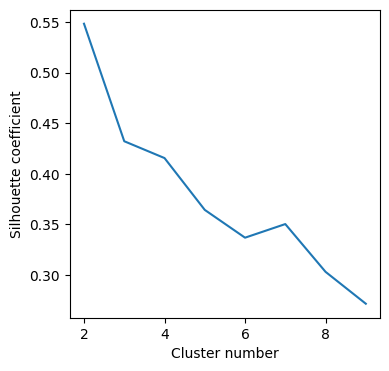

In [30]:
#a dataset is selected for the clustering task, including 4 attributes from the normalized dataset
clustering_dataset = my_working_dataset[['culmen_length_mm','culmen_depth_mm','flipper_length_mm', 'body_mass_g']]
#Creating a list of silhouette coefficient values
Silhouette_coefficient = []
#a loop with 9 iterations is implemented (9 different values for the number of clusters)
# 1 cluster is not considered in this case because it is not meaningful to calculate the silhouette coefficient 
#for 1 cluster
for i in range(2,10):
   #Creation of a K-means clustering model where the number of clusters (n_clusters) is equal to the loop 
#iteration number (2, 3..) 
   kmeans_model = KMeans(n_clusters = i, init = "k-means++")
   
   kmeans_model.fit(clustering_dataset)
   #Calculating the Silhouette coeffcient
   Silhouette_coefficient.append(metrics.silhouette_score(clustering_dataset, kmeans_model.labels_))
print(Silhouette_coefficient)
#representing the results visually
plt.figure(figsize=(4,4))
plt.plot(range(2,10), Silhouette_coefficient)
plt.xlabel('Cluster number')
plt.ylabel('Silhouette coefficient')
plt.show()

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0]


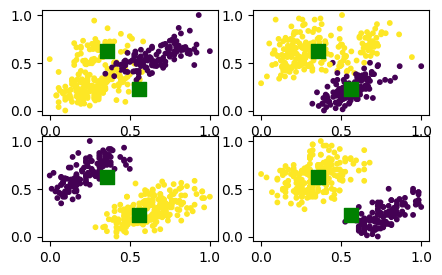

In [31]:
#a K-means model with 2 clusters is created and trained using the dataset with 4 features
kmeans_model = KMeans(n_clusters=2, init = "k-means++").fit(clustering_dataset)
#acquiring cluster centers
centroids = kmeans_model.cluster_centers_
#make predictions for cluster membership of data objects
y_pred = kmeans_model.predict(clustering_dataset)
print(y_pred)
plt.subplot(2,2,1)                            # A 2 x 2 matrix of images is created, index starting with 1 in the top left corner
plt.scatter(clustering_dataset['body_mass_g'], clustering_dataset['culmen_length_mm'], s = 10, c = y_pred)
plt.scatter(centroids[0,0], centroids[0,1], s = 100, c = 'g', marker = 's')
plt.scatter(centroids[1,0], centroids[1,1], s = 100, c = 'g', marker = 's')
plt.subplot(2,2,2)                            # Create the next image in the matrix with index 2
plt.scatter(clustering_dataset['culmen_length_mm'], clustering_dataset['culmen_depth_mm'], s = 10, c = y_pred)
plt.scatter(centroids[0,0], centroids[0,1], s = 100, c = 'g', marker = 's')
plt.scatter(centroids[1,0], centroids[1,1], s = 100, c = 'g', marker = 's')
plt.subplot(2,2,3)                            # Create the next image in the matrix with index 3
plt.scatter(clustering_dataset['culmen_depth_mm'], clustering_dataset['body_mass_g'], s = 10, c = y_pred)
plt.scatter(centroids[0,0], centroids[0,1], s = 100, c = 'g', marker = 's')
plt.scatter(centroids[1,0], centroids[1,1], s = 100, c = 'g', marker = 's')
plt.subplot(2,2,4)                            # Create the next image in the matrix with index 4
plt.scatter(clustering_dataset['flipper_length_mm'], clustering_dataset['culmen_depth_mm'], s = 10, c = y_pred)
plt.scatter(centroids[0,0], centroids[0,1], s = 100, c = 'g', marker = 's')
plt.scatter(centroids[1,0], centroids[1,1], s = 100, c = 'g', marker = 's')
plt.show()

### ***Hierarchical clustering***

In [32]:
clustering = AgglomerativeClustering().fit(clustering_dataset)

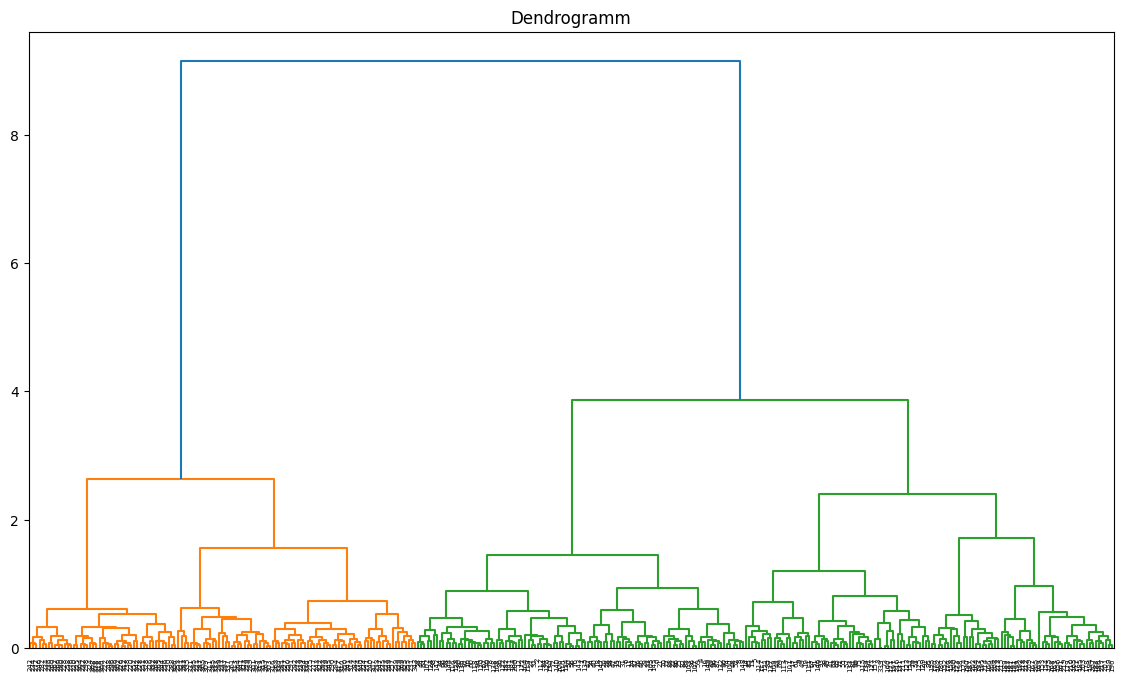

In [33]:
plt.figure(figsize =(14, 8))
plt.title('Dendrogramm')
Dendrogram = shc.dendrogram((shc.linkage(clustering_dataset, method ='ward')))
plt.show()

##How to find optimal number of clusters?

Look for the longest stretch of vertical line which is not crossed by any extended horizontal lines (here extended means horizontal lines i.e. the cluster dividers are extended infinitely to both directions). Now take any point on that stretch of line and draw an imaginary horizontal line. Count how many vertical lines this imaginary lines crossed. That is likely to be the optimal number of clusters. The idea is shown in the following figure. Here the optimal number of clusters could be 2.

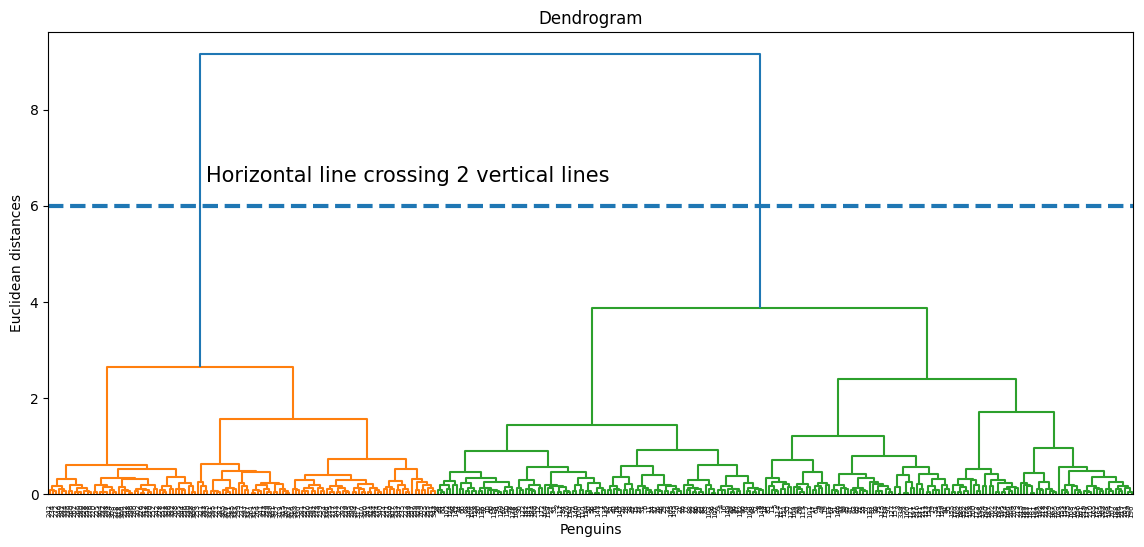

In [34]:
plt.figure(figsize=(14,6))
plt.title('Dendrogram')
plt.xlabel('Penguins')
plt.ylabel('Euclidean distances')
plt.hlines(y=6,xmin=0,xmax=4000,lw=3,linestyles='--')
plt.text(x=500,y=6.5,s='Horizontal line crossing 2 vertical lines',fontsize=15)
#plt.grid(True)
dendrogram = shc.dendrogram(shc.linkage(clustering_dataset, method = 'ward'))
plt.show()

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1]


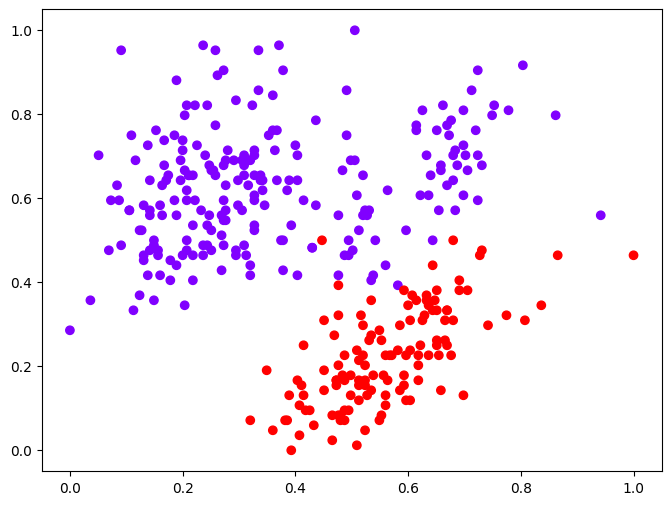

In [35]:
aggl_clust2 = AgglomerativeClustering(n_clusters = 2)
# Visualizing the clustering
plt.figure(figsize =(8, 6))
plt.scatter(clustering_dataset['culmen_length_mm'], clustering_dataset['culmen_depth_mm'], 
           c = aggl_clust2.fit_predict(clustering_dataset), cmap ='rainbow')
plt.show
print(aggl_clust2.fit_predict(clustering_dataset))

### ***DBSCAN***

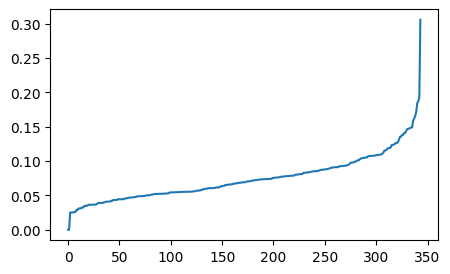

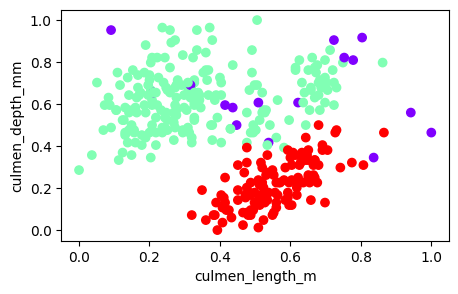

In [36]:
#identifying the potential value of epsilon
from sklearn.neighbors import NearestNeighbors # importing the library
neighbors = NearestNeighbors(n_neighbors=2) 
neighbor_model=neighbors.fit(clustering_dataset) # fitting the data to the object
distances,indices=neighbor_model.kneighbors(clustering_dataset) # finding the nearest neighbours
# Sort and plot the distances results
distances = np.sort(distances, axis = 0) # sorting the distances
distances = distances[:, 1] # taking the second column of the sorted distances
plt.rcParams['figure.figsize'] = (5,3) # setting the figure size
plt.plot(distances) # plotting the distances
plt.show() # showing the plot
from sklearn.cluster import DBSCAN
dbscan_clustering = DBSCAN(eps=0.15, min_samples=6).fit(clustering_dataset)
labels = dbscan_clustering.labels_
plt.scatter(clustering_dataset['culmen_length_mm'], clustering_dataset['culmen_depth_mm'], c = labels, cmap= "rainbow") # plotting the clusters
plt.xlabel("culmen_length_m") # X-axis label
plt.ylabel("culmen_depth_mm") # Y-axis label
plt.show() # showing the plot